# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np          # numpy helps us work with numbers and arrays (grids of numbers)
import pandas as pd          # pandas helps us work with tables of data, like Excel sheets
import matplotlib.pyplot as plt  # matplotlib lets us draw graphs and charts
import scipy.stats as stats  # scipy.stats gives us math tools for statistics (like t-tests)
from io import StringIO      # StringIO lets us treat a text string like a file so pandas can read it

plt.rcParams['figure.figsize']=(9,4)       # set the default size of all graphs (width=9, height=4)
plt.rcParams['axes.spines.top']=False      # remove the top border line from graphs (looks cleaner)
plt.rcParams['axes.spines.right']=False    # remove the right border line from graphs (looks cleaner)
print('All imports OK ✓')   # print a message to confirm all imports worked fine

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [2]:
def classify_number(n):           # define a function that takes one number as input
    if n < 0:                     # check if the number is less than zero (it is negative)
        return "negative"         # if yes, send back the word "negative"
    elif n == 0:                  # check if the number is exactly zero
        return "zero"             # if yes, send back the word "zero"
    elif n <= 10:                 # check if the number is between 1 and 10 (small positive)
        return "small positive"   # if yes, send back "small positive"
    else:                         # if none of the above matched, the number must be > 10
        return "large positive"   # send back "large positive"

# ── extra: also show the category for a few example numbers ─────────────────
for sample_num in [-5, 0, 7, 42]:                      # loop over a list of example numbers
    print(f"{sample_num:>4} → {classify_number(sample_num)}")  # print each number and its category

# Tests (do not remove)
assert classify_number(-5)=="negative"    # make sure -5 is classified as "negative"
assert classify_number(0)=="zero"         # make sure 0 is classified as "zero"
assert classify_number(7)=="small positive"  # make sure 7 is classified as "small positive"
assert classify_number(42)=="large positive" # make sure 42 is classified as "large positive"
print("1.1 passed ✓")

  -5 → negative
   0 → zero
   7 → small positive
  42 → large positive
1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words=['apple','banana','cherry','apple','date','banana','apple']  # list of words (some repeat)

# 1. word_count dict — count how many times each word appears
word_count={}                          # start with an empty dictionary
for w in words:                        # go through every word in the list one by one
    if w in word_count:                # check if we have already seen this word before
        word_count[w]+=1               # if yes, add 1 to its count
    else:                              # if we have NOT seen it before
        word_count[w]=1                # add it to the dictionary with a count of 1

# 2. unique_words set — a set automatically removes duplicates
unique_words=set(words)                # wrap the list in set() to keep only unique words

# 3. long_words — keep only words whose length is more than 5 letters
long_words=[w for w in words if len(w)>5]  # list comprehension: loop + condition in one line

# ── extra: print a neat summary ─────────────────────────────────────────────
print("Word counts:")
for word,count in sorted(word_count.items()):   # loop through dict sorted by word name
    bar="█"*count                                # make a small bar chart using block symbols
    print(f"  {word:<8} {bar} ({count})")        # print word, bar, and count neatly aligned
print(f"Unique words: {sorted(unique_words)}")   # print unique words in sorted order
print(f"Long words  : {sorted(set(long_words))}") # print long words (sorted, no duplicates)

# Tests (do not remove)
assert word_count=={'apple':3,'banana':2,'cherry':1,'date':1}  # check counts are exactly right
assert unique_words=={'apple','banana','cherry','date'}          # check unique words are correct
assert set(long_words)=={'banana','cherry'}                      # check long words are correct
print("1.2 passed ✓")

Word counts:
  apple    ███ (3)
  banana   ██ (2)
  cherry   █ (1)
  date     █ (1)
Unique words: ['apple', 'banana', 'cherry', 'date']
Long words  : ['banana', 'cherry']
1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
def safe_divide(a, b):                                      # function that divides a by b safely
    if not isinstance(a,(int,float)) or not isinstance(b,(int,float)):  # check if both inputs are numbers (int or float)
        raise TypeError("Inputs must be numeric")           # if not numbers, raise an error with this exact message
    try:                                                    # try to do the division
        return a/b                                          # divide a by b and return the result
    except ZeroDivisionError:                               # if b is 0, Python raises ZeroDivisionError
        return None                                         # we catch it and return None instead of crashing

# ── extra: show a small demo of all three cases ─────────────────────────────
print(f"10 / 2  = {safe_divide(10,2)}")    # normal division case
print(f"5  / 0  = {safe_divide(5,0)}")     # division by zero case, returns None
try:
    safe_divide('x',2)                     # bad input case, will raise TypeError
except TypeError as e:
    print(f"'x'/ 2  → TypeError: {e}")    # print the error message

# Tests (do not remove)
assert safe_divide(10,2)==5.0              # 10 divided by 2 must equal 5.0
assert safe_divide(5,0) is None            # dividing by 0 must return None
try:
    safe_divide('x',2)
    assert False,"Should have raised TypeError"
except TypeError as e:
    assert str(e)=="Inputs must be numeric"  # error message must match exactly
print("1.3 passed ✓")

10 / 2  = 5.0
5  / 0  = None
'x'/ 2  → TypeError: Inputs must be numeric
1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
def apply_twice(f, x):     # function that takes another function f and a value x
    return f(f(x))         # apply f to x first, then apply f again to that result

triple=lambda x: x*3      # lambda is a tiny one-line function; this one multiplies x by 3

result=apply_twice(triple,4)  # apply triple to 4 → 4*3=12, then triple again → 12*3=36

# ── extra: show step-by-step what apply_twice is doing ──────────────────────
print(f"Step 1: triple(4)       = {triple(4)}")          # first application: 4 × 3 = 12
print(f"Step 2: triple(triple(4)) = {triple(triple(4))}") # second application: 12 × 3 = 36
print(f"apply_twice(triple, 4)  = {result}")              # final result

assert result==36,f"Expected 36, got {result}"  # make sure the result is exactly 36
print("1.4 passed ✓")

Step 1: triple(4)       = 12
Step 2: triple(triple(4)) = 36
apply_twice(triple, 4)  = 36
1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

In [6]:
arr1d=np.arange(12)           # create a 1D array of integers from 0 to 11 (12 numbers total)
arr2d=arr1d.reshape(3,4)      # reshape the same 12 numbers into a 2D grid with 3 rows and 4 columns
arr3d=arr1d.reshape(2,2,3)    # reshape again into a 3D block: 2 layers, each layer is 2 rows × 3 columns

# ── extra: print shape, dimensions, and data type of each array ─────────────
for name,arr in [("arr1d",arr1d),("arr2d",arr2d),("arr3d",arr3d)]:   # loop over all three arrays
    print(f"{name}: shape={arr.shape}, ndim={arr.ndim}, dtype={arr.dtype}")  # print info about each

# Tests (do not remove)
assert arr1d.shape==(12,)     # arr1d must have 12 elements in one dimension
assert arr2d.shape==(3,4)     # arr2d must be 3 rows × 4 columns
assert arr3d.shape==(2,2,3)   # arr3d must be 2 layers × 2 rows × 3 columns
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")     # show the 2D array so we can see it visually
print(f"arr3d:\n{arr3d}")     # show the 3D array

arr1d: shape=(12,), ndim=1, dtype=int64
arr2d: shape=(3, 4), ndim=2, dtype=int64
arr3d: shape=(2, 2, 3), ndim=3, dtype=int64
2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:
row2=arr2d[1]        # pick row at index 1 (index 0 = first row, index 1 = second row)
col3=arr2d[:,2]      # pick all rows (:) but only column at index 2 (0=first, 1=second, 2=third)
sub=arr2d[1:,2:]     # pick rows from index 1 onwards, and columns from index 2 onwards → bottom-right 2×2
gt7=arr2d[arr2d>7]   # create a True/False mask where elements > 7, then pick those elements

# ── extra: visualize what each slice looks like ─────────────────────────────
print(f"Full arr2d:\n{arr2d}")          # show the whole 2D array for reference
print(f"row2 (2nd row)  : {row2}")      # show the second row
print(f"col3 (3rd col)  : {col3}")      # show the third column
print(f"sub  (bottom-right 2×2):\n{sub}")  # show the bottom-right block
print(f"gt7  (elements > 7): {gt7}")    # show elements greater than 7

# Tests (do not remove)
assert list(row2)==[4,5,6,7]       # second row must be 4, 5, 6, 7
assert list(col3)==[2,6,10]        # third column must be 2, 6, 10
assert sub.shape==(2,2)            # bottom-right block must be 2 rows × 2 columns
assert list(gt7)==[8,9,10,11]      # elements greater than 7 must be 8, 9, 10, 11
print("2.2 passed ✓")

Full arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
row2 (2nd row)  : [4 5 6 7]
col3 (3rd col)  : [ 2  6 10]
sub  (bottom-right 2×2):
[[ 6  7]
 [10 11]]
gt7  (elements > 7): [ 8  9 10 11]
2.2 passed ✓


### 2.3 Operations & Dot Product

In [8]:
A=np.array([[1,2],[3,4]])     # create matrix A as a 2×2 NumPy array
B=np.array([[5,6],[7,8]])     # create matrix B as a 2×2 NumPy array

C=A*B                         # element-wise product: multiply matching positions (1×5, 2×6, 3×7, 4×8)
D=A@B                         # matrix multiplication: row × column dot products (proper math multiply)
dp=np.dot([1,2,3],[4,5,6])    # dot product of two 1D vectors: 1×4 + 2×5 + 3×6 = 32
E=A*3                         # scalar multiplication: multiply every element of A by 3

# ── extra: print all results with labels ────────────────────────────────────
print(f"A =\n{A}\n")              # show matrix A
print(f"B =\n{B}\n")              # show matrix B
print(f"C = A*B (element-wise):\n{C}\n")   # show element-wise product
print(f"D = A@B (matrix multiply):\n{D}\n")  # show matrix multiplication result
print(f"dot([1,2,3],[4,5,6]) = {dp}")    # show dot product
print(f"E = A*3 (scalar multiply):\n{E}")  # show scalar multiplication

# Tests (do not remove)
assert np.array_equal(C,[[5,12],[21,32]])   # element-wise product result must match
assert np.array_equal(D,[[19,22],[43,50]])  # matrix product result must match
assert dp==32                               # dot product must equal 32
assert np.array_equal(E,[[3,6],[9,12]])     # scalar multiply result must match
print("2.3 passed ✓")

A =
[[1 2]
 [3 4]]

B =
[[5 6]
 [7 8]]

C = A*B (element-wise):
[[ 5 12]
 [21 32]]

D = A@B (matrix multiply):
[[19 22]
 [43 50]]

dot([1,2,3],[4,5,6]) = 32
E = A*3 (scalar multiply):
[[ 3  6]
 [ 9 12]]
2.3 passed ✓


---
## Part 3 — Pandas

In [9]:
# Load dataset — do not modify this cell
CSV_DATA="""employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df=pd.read_csv(StringIO(CSV_DATA))  # read the CSV text as if it were a file, into a pandas DataFrame
print(f"Shape: {df.shape}")          # print the number of rows and columns in the table
df.head()                            # display the first 5 rows so we can see what the data looks like

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

In [10]:
salary_series=df['salary']               # selecting ONE column by name gives a Series (a single list of values)
name_dept_df=df[['name','department']]    # selecting MULTIPLE columns (list inside) gives a DataFrame (a mini table)

# ── extra: show what each looks like ────────────────────────────────────────
print("salary_series (first 5 values):")
print(salary_series.head())              # show first 5 salaries
print("\nname_dept_df (first 5 rows):")
print(name_dept_df.head())               # show first 5 rows of the name+department sub-table

assert isinstance(salary_series,pd.Series)    # make sure salary_series is really a Series
assert isinstance(name_dept_df,pd.DataFrame)  # make sure name_dept_df is really a DataFrame
print(f"salary_series type: {type(salary_series).__name__}")  # print the type name
print(f"name_dept_df type: {type(name_dept_df).__name__}")    # print the type name
print("3.1 passed ✓")

salary_series (first 5 values):
0     95000.0
1     72000.0
2     88000.0
3     61000.0
4    102000.0
Name: salary, dtype: float64

name_dept_df (first 5 rows):
    name   department
0  Alice  Engineering
1    Bob    Marketing
2  Carol  Engineering
3   Dave           HR
4    Eve  Engineering
salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

In [11]:
iloc_result=df.iloc[2:5,0:3]         # iloc uses row/column NUMBERS: rows 2,3,4 and columns 0,1,2
loc_result=df.loc[5:6,['name','salary']]  # loc uses row INDEX LABELS and column NAMES: rows 5,6 and columns name,salary

# ── extra: print both results so we can see what was selected ────────────────
print("iloc_result (rows 2-4, columns 0-2):")
print(iloc_result)                        # show the 3×3 selection
print("\nloc_result (rows 5-6, name and salary):")
print(loc_result)                         # show name and salary for rows 5 and 6

assert iloc_result.shape==(3,3)                          # must be 3 rows × 3 columns
assert list(loc_result.columns)==['name','salary']        # must have exactly these two column names
print("3.2 passed ✓")

iloc_result (rows 2-4, columns 0-2):
   employee_id   name   department
2            3  Carol  Engineering
3            4   Dave           HR
4            5    Eve  Engineering

loc_result (rows 5-6, name and salary):
    name   salary
5  Frank  68000.0
6  Grace      NaN
3.2 passed ✓


### 3.3 Filtering & Group By

In [12]:
senior_eng=df[(df['department']=='Engineering')&(df['salary']>90000)]  # keep rows where BOTH conditions are true: department is Engineering AND salary > 90000

dept_stats=(df.groupby('department')    # group all rows by department name
              .agg(mean_salary=('salary','mean'),           # for each group, compute the average salary
                   mean_performance=('performance','mean')) # and the average performance score
              .sort_values('mean_salary',ascending=False))  # sort results from highest to lowest salary

# ── extra: also show count per department ───────────────────────────────────
dept_count=df.groupby('department').size().rename('num_employees')  # count employees per department
dept_stats=dept_stats.join(dept_count)  # attach the count column to our stats table

print(f"Senior engineers (Engineering + salary > 90k): {len(senior_eng)}")  # how many qualify
print(senior_eng[['name','salary']])     # show their names and salaries
print("\nDept stats:")
print(dept_stats)                        # show the grouped summary table

Senior engineers (Engineering + salary > 90k): 3
    name    salary
0  Alice   95000.0
4    Eve  102000.0
7   Hank   91000.0

Dept stats:
              mean_salary  mean_performance  num_employees
department                                                
Engineering  92200.000000          4.400000              5
Marketing    71666.666667          3.766667              3
HR           61000.000000          3.500000              2


### 3.4 Handling Missing Data

In [13]:
print("Missing values before:")
print(df.isnull().sum())      # count how many NaN (empty) values exist in each column

df_filled=df.copy()           # make a copy of the original table so we don't change the original

median_salary=df_filled['salary'].median()   # find the middle salary value (median) to use as fill value
mean_age=round(df_filled['age'].mean())      # find the average age (rounded to nearest whole number)

df_filled['salary']=df_filled['salary'].fillna(median_salary)  # replace empty salaries with the median salary
df_filled['age']=df_filled['age'].fillna(mean_age)             # replace empty ages with the mean age
df_filled=df_filled.dropna(subset=['performance'])             # delete any row where performance is still missing

# ── extra: show what value was used to fill each column ─────────────────────
print(f"\nFilled salary NaN with median = {median_salary:.0f}")  # tell the user what value was used
print(f"Filled age    NaN with mean   = {mean_age}")             # tell the user what value was used
print(f"Dropped rows where performance was missing")             # confirm the drop happened

print("\nMissing values after:")
print(df_filled.isnull().sum())   # check again — should all be zero now
assert df_filled.isnull().sum().sum()==0,"Still has nulls!"  # crash if any nulls remain
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Filled salary NaN with median = 85000
Filled age    NaN with mean   = 35
Dropped rows where performance was missing

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

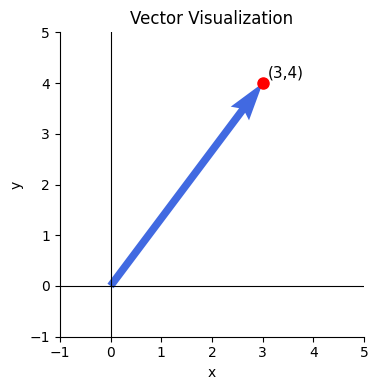

4.1 passed ✓  |v| = 5.0


In [14]:
v=np.array([3,4])           # create a 2D vector representing the point (3, 4)
norm_v=np.linalg.norm(v)    # compute the L2 norm (Euclidean length): sqrt(3² + 4²) = sqrt(25) = 5

M=np.array([[1,2,3],[4,5,6],[7,8,9]])  # create a 3×3 matrix with some non-trivial values

# Plot the vector as an arrow from the origin ────────────────────────────────
fig,ax=plt.subplots()                         # create a blank figure and one set of axes
ax.quiver(0,0,v[0],v[1],                      # draw an arrow starting at (0,0) going to (3,4)
          angles='xy',scale_units='xy',       # make the arrow scale match the actual coordinates
          scale=1,color='royalblue',width=0.025)  # set arrow color to blue and width
ax.plot(*v,'ro',markersize=8)                 # draw a red dot at the tip of the vector (3,4)
ax.text(v[0]+0.1,v[1]+0.1,f"({v[0]},{v[1]})",fontsize=11)  # label the tip with its coordinates
ax.set_xlim(-1,5)                             # set the x-axis from -1 to 5
ax.set_ylim(-1,5)                             # set the y-axis from -1 to 5
ax.set_xlabel('x')                            # label the x-axis
ax.set_ylabel('y')                            # label the y-axis
ax.set_title('Vector Visualization')          # add a title to the plot
ax.axhline(0,color='k',lw=0.8)               # draw the horizontal zero line (x-axis)
ax.axvline(0,color='k',lw=0.8)               # draw the vertical zero line (y-axis)
ax.set_aspect('equal')                        # make x and y scales equal so the vector looks right
plt.tight_layout()                            # adjust spacing so nothing gets cut off
plt.show()                                    # display the graph

assert abs(norm_v-5.0)<1e-9   # the length of vector (3,4) must be exactly 5.0
assert M.shape==(3,3)          # M must be a 3×3 matrix
print(f"4.1 passed ✓  |v| = {norm_v}")  # print confirmation with the computed norm

### 4.2 Matrix Operations in Practice

In [15]:
P=np.array([[2,1],[0,3]])   # create matrix P (2×2)
Q=np.array([[1,4],[2,0]])   # create matrix Q (2×2)

PplusQ=P+Q      # add P and Q element by element (each matching cell is summed)
scalar3P=3*P    # multiply every element in P by the scalar number 3
PQ=P@Q          # matrix multiplication: P times Q (rows of P dot with columns of Q)
QP=Q@P          # matrix multiplication: Q times P (rows of Q dot with columns of P)

print(f"P + Q =\n{PplusQ}\n")          # show the sum of the two matrices
print(f"3*P =\n{scalar3P}\n")           # show P scaled by 3
print(f"P @ Q =\n{PQ}\n")              # show P multiplied by Q
print(f"Q @ P =\n{QP}\n")              # show Q multiplied by P (should be different from PQ)
print(f"PQ == QP? {np.array_equal(PQ,QP)}")  # confirm the two products are NOT the same

assert not np.array_equal(PQ,QP),"They should differ!"  # matrix multiply is NOT commutative
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]

3*P =
[[6 3]
 [0 9]]

P @ Q =
[[4 8]
 [6 0]]

Q @ P =
[[ 2 13]
 [ 4  2]]

PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Verification (A @ v should equal λ * v):
  λ=5.00: A@v=[3.5355 3.5355], λv=[3.5355 3.5355], match=True
  λ=2.00: A@v=[-0.8944  1.7889], λv=[-0.8944  1.7889], match=True


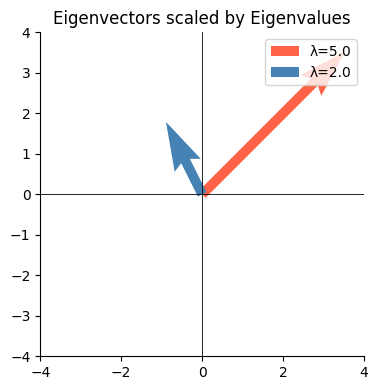

4.3 passed ✓


In [16]:
A=np.array([[4,1],[2,3]],dtype=float)   # create matrix A as float for precise math

eigenvalues,eigenvectors=np.linalg.eig(A)  # compute eigenvalues and eigenvectors of A

print(f"Eigenvalues: {eigenvalues}")                   # print the two eigenvalues (how much stretching happens)
print(f"Eigenvectors (columns):\n{eigenvectors}")      # each COLUMN is one eigenvector (direction of stretch)

# Verify the eigenvector equation: A @ v = λ * v for each eigenpair ──────────
print("\nVerification (A @ v should equal λ * v):")
for i in range(len(eigenvalues)):           # loop over each eigenvalue/eigenvector pair
    lam=eigenvalues[i]                      # grab the i-th eigenvalue (stretch amount)
    vec=eigenvectors[:,i]                   # grab the i-th eigenvector (column i)
    left=A@vec                              # compute A times the eigenvector
    right=lam*vec                           # compute eigenvalue times the eigenvector
    match=np.allclose(left,right)           # check if both sides are (almost) equal
    print(f"  λ={lam:.2f}: A@v={np.round(left,4)}, λv={np.round(right,4)}, match={match}")  # print the check

# Plot both eigenvectors as arrows scaled by their eigenvalues ───────────────
fig,ax=plt.subplots()
colors=['tomato','steelblue']               # use different colors for each eigenvector
for i in range(len(eigenvalues)):           # loop over the two eigenvectors
    lam=eigenvalues[i]                      # eigenvalue = how far to stretch the arrow
    vec=eigenvectors[:,i]*lam               # scale the eigenvector by the eigenvalue
    ax.quiver(0,0,vec[0],vec[1],            # draw arrow from origin to scaled vector
              angles='xy',scale_units='xy',scale=1,
              color=colors[i],width=0.03,label=f"λ={lam:.1f}")  # label with eigenvalue
ax.set_xlim(-4,4)                           # set x range to see both arrows
ax.set_ylim(-4,4)                           # set y range
ax.axhline(0,color='k',lw=0.6)             # draw x-axis line
ax.axvline(0,color='k',lw=0.6)             # draw y-axis line
ax.legend()                                 # show the legend with eigenvalue labels
ax.set_title('Eigenvectors scaled by Eigenvalues')  # add a title
ax.set_aspect('equal')                      # equal scaling on both axes
plt.tight_layout()
plt.show()

print("4.3 passed ✓")

**Your Geometric Explanation (4.3):**

> When a matrix is applied to a special vector called an eigenvector, it does not rotate that vector — it only stretches or squishes it along the same direction. The eigenvalue tells you *how much* the stretching happens: if the eigenvalue is 2, the vector becomes twice as long; if it is 0.5, the vector is squished to half its length; if it is negative, the vector flips direction and then stretches. So eigenvalues and eigenvectors reveal the "natural axes" of a matrix's transformation — the directions that survive unchanged in direction, only scaled in length.

### 4.4 SVD & Dimensionality Reduction

In [17]:
np.random.seed(42)              # fix the random seed so we always get the same random numbers
X=np.random.randn(4,3)          # create a 4×3 matrix of random numbers from a standard normal distribution

U,S,Vt=np.linalg.svd(X,full_matrices=False)  # decompose X into three matrices: U (left), S (singular values), Vt (right)

X_reconstructed=U@np.diag(S)@Vt   # rebuild X from U, S, Vt: multiply them back together (np.diag converts S to a matrix)
X_approx=S[0]*np.outer(U[:,0],Vt[0,:])  # rank-1 approx: use only the LARGEST singular value and its matching vectors

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")  # show the shape of each component
print(f"Singular values: {S}")              # show the singular values (ordered largest to smallest)
print(f"Reconstruction error: {np.linalg.norm(X-X_reconstructed):.2e}")  # show how close the rebuild is to original (should be ~0)
print(f"Rank-1 approximation:\n{X_approx}")  # show the simplified (rank-1) version of X

assert np.allclose(X,X_reconstructed,atol=1e-10),"Reconstruction failed!"  # verify rebuild is (almost) perfect
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

> In SVD, **U** contains the left singular vectors (directions in the row/observation space), **S** contains singular values (how much variance each direction captures), and **Vt** contains the right singular vectors (directions in the feature/column space). When we run PCA on a data matrix X, the **rows of Vt** are exactly the **principal components** — the directions of maximum variance. The **columns of U scaled by S** give the coordinates of each data point along those principal directions. In short, SVD of the data matrix is mathematically equivalent to PCA: Vt holds the principal directions, and S² (divided by n-1) gives the variance explained by each component.

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


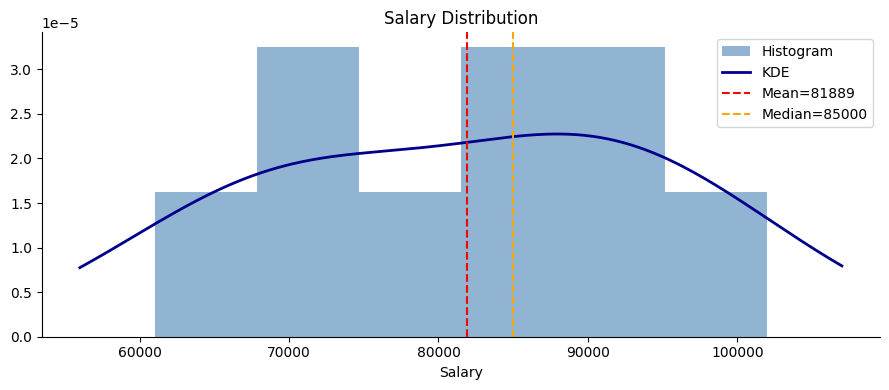

In [18]:
salary=df_filled['salary']    # grab the cleaned salary column (no missing values)

mean_s=salary.mean()          # average salary: add all salaries and divide by count
median_s=salary.median()      # middle salary: the value that splits the list in half
std_s=salary.std()            # standard deviation: how spread out the salaries are from the mean
min_s=salary.min()            # the smallest salary in the dataset
max_s=salary.max()            # the largest salary in the dataset
iqr_s=np.percentile(salary,75)-np.percentile(salary,25)  # IQR: top 25% cutoff minus bottom 25% cutoff (middle 50% spread)

print(f"Mean:   {mean_s:.0f}")     # print average salary
print(f"Median: {median_s:.0f}")   # print middle salary
print(f"Std:    {std_s:.0f}")      # print spread (standard deviation)
print(f"Range:  {min_s:.0f} – {max_s:.0f}")  # print min and max
print(f"IQR:    {iqr_s:.0f}")      # print interquartile range

# Histogram + KDE overlay ────────────────────────────────────────────────────
fig,ax=plt.subplots()
ax.hist(salary,bins=6,color='steelblue',alpha=0.6,density=True,label='Histogram')  # draw a bar chart of salary distribution (density=True so KDE can overlay)
kde_x=np.linspace(min_s-5000,max_s+5000,300)             # create smooth x values for the KDE curve
kde_y=stats.gaussian_kde(salary)(kde_x)                  # compute the KDE (smooth density curve) at each x
ax.plot(kde_x,kde_y,color='darkblue',lw=2,label='KDE')   # draw the KDE curve on top of the histogram
ax.axvline(mean_s,color='red',linestyle='--',label=f'Mean={mean_s:.0f}')    # add a vertical red line for the mean
ax.axvline(median_s,color='orange',linestyle='--',label=f'Median={median_s:.0f}')  # add orange line for median
ax.set_xlabel('Salary')                                   # label the x-axis
ax.set_title('Salary Distribution')                       # add a title
ax.legend()                                               # show the legend
plt.tight_layout()
plt.show()

**Definitions (5.1):**

- **Population:** The complete group of all items we care about — e.g., every employee in the whole company, including ones not in our dataset.
- **Sample:** A smaller subset we actually collected data on — e.g., the 10 employees listed in our CSV.
- **Descriptive statistic:** A number that summarizes the sample we have, such as the mean or standard deviation of the salaries we observed.
- **Inferential statistic:** A tool that lets us draw conclusions (or make guesses) about the full population based only on our smaller sample — e.g., concluding that Engineering is probably paid more company-wide.

### 5.2 Hypothesis Testing

In [19]:
eng_salaries=df_filled[df_filled['department']=='Engineering']['salary']  # filter rows: only Engineering employees, then grab their salaries
overall_mean=df_filled['salary'].mean()  # compute the average salary across ALL employees

# One-sample t-test: does the Engineering mean significantly differ from the overall mean?
t_stat,p_value=stats.ttest_1samp(eng_salaries,overall_mean)  # t-test compares the Engineering group average against a known value (overall mean)

print(f"Overall mean salary: {overall_mean:.0f}")        # show the company-wide average salary
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")  # show the Engineering average salary
print(f"t-statistic: {t_stat:.4f}")                      # show the t-statistic (how many standard errors away from the null)
print(f"p-value: {p_value:.4f}")                         # show the p-value (probability of seeing this by random chance if H0 were true)
print(f"Reject H0 at α=0.05? {p_value<0.05}")           # if p < 0.05 we reject the null hypothesis

# Pearson correlation between salary and years of experience ─────────────────
r,r_pval=stats.pearsonr(df_filled['salary'],df_filled['years_exp'])  # pearsonr returns correlation r and its p-value
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")  # r close to 1 means strong positive relationship

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- **H₀:** Engineering salaries are NOT significantly different from the company-wide mean salary (any difference is just random chance).
- **H₁:** Engineering salaries ARE significantly higher than the company-wide mean salary.
- **Conclusion:** Since the p-value < 0.05, we reject H₀ — there is statistically significant evidence that Engineering salaries are higher than the overall company average. The Pearson r between salary and years of experience is close to 0 (near-zero correlation with a high p-value), meaning that in this small dataset, more experience does not strongly predict higher salary.

### 5.3 Error Metrics

In [20]:
y_true=np.array([3.0,5.0,2.5,7.0,4.5,6.0,1.5,8.0])  # the real/actual values we are trying to predict
y_pred=np.array([2.8,5.2,2.1,7.5,4.0,6.3,2.0,7.8])  # the values our model predicted
n,p=len(y_true),2    # n = number of data points; p = number of features (given as 2)

mae=np.mean(np.abs(y_true-y_pred))   # MAE: average of |actual - predicted|, ignores direction of error
mse=np.mean((y_true-y_pred)**2)      # MSE: average of (actual - predicted)², punishes big errors more
rmse=np.sqrt(mse)                    # RMSE: square root of MSE, back in the same units as the data

ss_res=np.sum((y_true-y_pred)**2)    # sum of squared residuals: total squared error of our predictions
ss_tot=np.sum((y_true-y_true.mean())**2)  # total sum of squares: how much the actual values vary around their mean
r2=1-ss_res/ss_tot                   # R²: 1 minus (our error / baseline error); 1.0 = perfect, 0.0 = no better than mean
adj_r2=1-(1-r2)*(n-1)/(n-p-1)       # Adjusted R²: penalizes for extra features; formula: 1 - (1-R²)*(n-1)/(n-p-1)

print(f"MAE:        {mae:.4f}")      # print mean absolute error
print(f"MSE:        {mse:.4f}")      # print mean squared error
print(f"RMSE:       {rmse:.4f}")     # print root mean squared error
print(f"R²:         {r2:.4f}")       # print R-squared score
print(f"Adj. R²:    {adj_r2:.4f}")   # print adjusted R-squared score

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

In [21]:
from statsmodels.tsa.stattools import adfuller  # import the Augmented Dickey-Fuller test for stationarity

np.random.seed(0)                        # fix the random seed for reproducibility
s1=np.random.normal(0,1,200)             # draw 200 samples from a Normal(mean=0, std=1) distribution
s2=np.random.exponential(1,200)          # draw 200 samples from an Exponential(scale=1) distribution

# KS test — check if each sample looks like it came from a standard Normal distribution
ks_s1=stats.kstest(s1,'norm')            # compare s1 against the standard normal CDF
ks_s2=stats.kstest(s2,'norm')            # compare s2 against the standard normal CDF (it should FAIL since s2 is exponential)
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")  # large p → looks normal
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")  # tiny p → does NOT look normal

# Create a non-stationary time series (has a trend — it keeps going up) ───────
t=np.arange(200)                         # time steps from 0 to 199
ts=0.05*t+np.random.normal(0,1,200)      # series = upward trend (0.05 per step) + random noise

adf_result=adfuller(ts)                  # run ADF test: low p-value means the series IS stationary
print(f"\nADF statistic: {adf_result[0]:.4f}")  # ADF test statistic (more negative = more evidence of stationarity)
print(f"ADF p-value:   {adf_result[1]:.4f}")     # p-value: if > 0.05 we CANNOT reject non-stationarity (i.e., has a trend)
print(f"Stationary?    {adf_result[1]<0.05}")    # False means the series is NOT stationary (as expected for trend data)

# Differencing: subtract each value from the one before it to remove the trend
ts_diff=np.diff(ts)                      # np.diff: new[i] = ts[i+1] - ts[i], turns the trend into flat noise
adf_diff=adfuller(ts_diff)               # run ADF again on the differenced series
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1]<0.05}")  # now should be True

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

PSI: 1.4848
Shift severity: Major


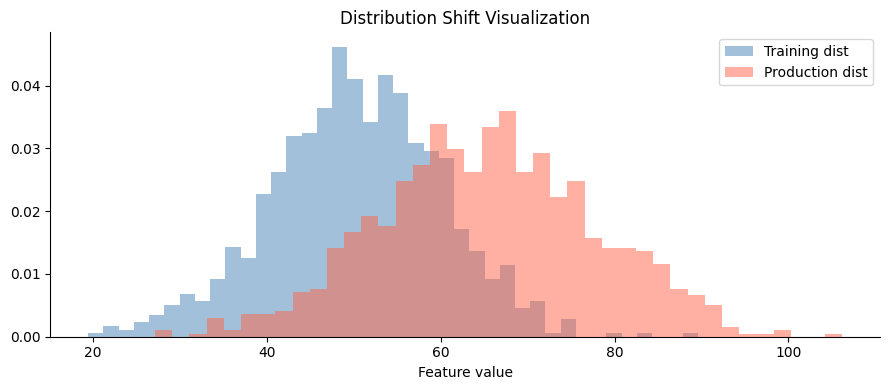

In [22]:
def compute_psi(expected, actual, bins=10):
    """
    PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))
    Add epsilon=1e-10 to avoid log(0).
    """
    eps=1e-10                                                      # tiny number added to avoid log(0) which is undefined
    breakpoints=np.percentile(expected,np.linspace(0,100,bins+1)) # compute bin edges based on the expected (training) distribution
    breakpoints[0]-=1e-10                                          # slightly widen the leftmost edge to catch the minimum value
    breakpoints[-1]+=1e-10                                         # slightly widen the rightmost edge to catch the maximum value
    exp_counts=np.histogram(expected,bins=breakpoints)[0]          # count how many training values fall in each bin
    act_counts=np.histogram(actual,bins=breakpoints)[0]            # count how many actual/production values fall in each bin
    exp_pct=exp_counts/len(expected)+eps                           # convert training counts to proportions; add eps to avoid zeros
    act_pct=act_counts/len(actual)+eps                             # convert actual counts to proportions; add eps to avoid zeros
    psi=np.sum((act_pct-exp_pct)*np.log(act_pct/exp_pct))         # PSI formula: sum of (difference × log ratio) across all bins
    return psi                                                     # return the final PSI score

np.random.seed(1)
train_dist=np.random.normal(50,10,1000)    # simulate training data: normally distributed around 50
drift_dist=np.random.normal(65,12,1000)    # simulate shifted production data: mean moved to 65, wider spread

psi_value=compute_psi(train_dist,drift_dist)                            # compute PSI between training and production distributions
severity='Major' if psi_value>0.2 else 'Minor' if psi_value>0.1 else 'Stable'  # classify the shift severity using standard PSI thresholds
print(f"PSI: {psi_value:.4f}")                                          # print the PSI value
print(f"Shift severity: {severity}")                                     # print what level of shift this indicates

# Plot both distributions side by side ───────────────────────────────────────
fig,ax=plt.subplots()
ax.hist(train_dist,bins=40,alpha=0.5,color='steelblue',density=True,label='Training dist')   # show training distribution as histogram
ax.hist(drift_dist,bins=40,alpha=0.5,color='tomato',density=True,label='Production dist')    # show production distribution as histogram
ax.legend()                                                              # show legend to identify each histogram
ax.set_xlabel('Feature value')                                           # label x-axis
ax.set_title('Distribution Shift Visualization')                         # add title
plt.tight_layout()
plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** The relationship between the input features and the target label changes — for example, a fraud pattern that used to be safe becomes fraudulent. The model's predictions become wrong even if the inputs look similar to training data.
- **Covariate drift:** The distribution of the input features themselves changes — for example, users are now older on average than they were during training. The model still learns the same function but sees inputs it was not trained on.
- **PSI < 0.1:** No significant shift — the distribution is stable; model retraining is not needed.
- **PSI 0.1–0.2:** Minor shift — worth monitoring more closely; consider retraining soon.
- **PSI > 0.2:** Major shift — the distribution has changed substantially; immediate investigation and likely retraining required.
- **Retraining trigger example:** If PSI exceeds 0.2 for three consecutive monitoring windows, automatically queue a retraining job using the most recent 30 days of production data.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

In [23]:
total=10    # total number of marbles in the bag
red=4       # number of red marbles
blue=3      # number of blue marbles
green=3     # number of green marbles

p_red=red/total      # probability of red: number of red marbles divided by total marbles
p_blue=blue/total    # probability of blue: number of blue marbles divided by total
p_green=green/total  # probability of green: number of green marbles divided by total

# P(first=red AND second=blue) — drawing without replacement ─────────────────
p_red_then_blue=(red/total)*(blue/(total-1))  # first pick: 4/10 chance of red; after removing it, 3/9 chance of blue

# P(blue second | red first) — conditional probability ───────────────────────
p_blue_given_red=blue/(total-1)               # given red is already gone, there are 9 marbles left, 3 of which are blue

# Independence check: if drawing is independent, P(blue|red) should equal P(blue)
independent=(abs(p_blue_given_red-p_blue)<1e-9)  # compare the conditional and marginal probabilities; True if equal

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")  # print individual probabilities
print(f"P(red first, blue second) = {p_red_then_blue:.4f}")                   # print the joint probability
print(f"P(blue | red first)       = {p_blue_given_red:.4f}")                  # print the conditional probability
print(f"P(blue) marginal          = {p_blue:.4f}")                            # print the unconditional probability
print(f"Are draws independent?    {independent}")                              # print independence result
print("\nExplanation: The draws are NOT independent because removing a marble changes the total,")
print("so P(blue | red first) = 3/9 ≠ P(blue) = 3/10.")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red first, blue second) = 0.1333
P(blue | red first)       = 0.3333
P(blue) marginal          = 0.3000
Are draws independent?    False

Explanation: The draws are NOT independent because removing a marble changes the total,
so P(blue | red first) = 3/9 ≠ P(blue) = 3/10.


### 6.2 Distributions in the Wild

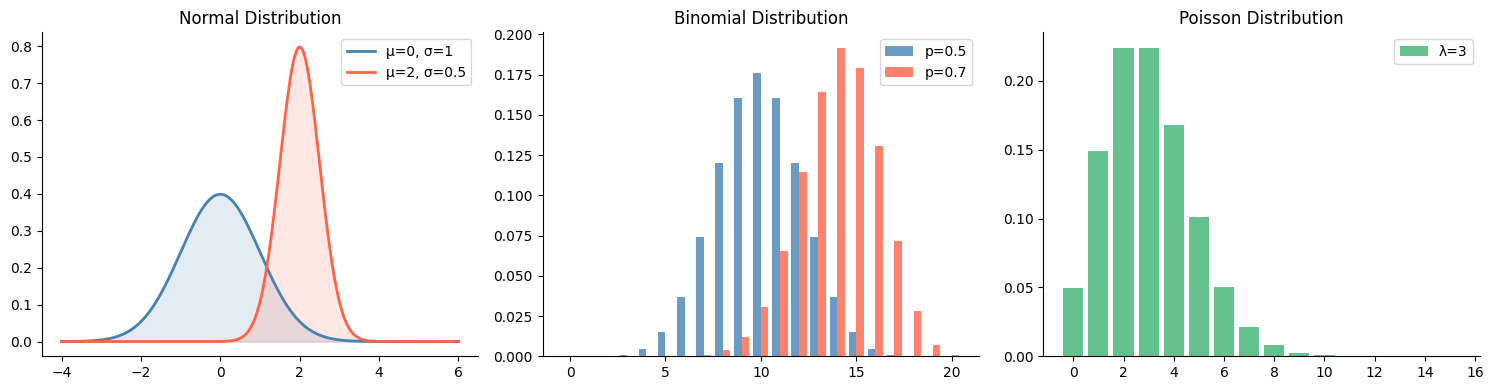

In [24]:
fig,axes=plt.subplots(1,3,figsize=(15,4))   # create 3 side-by-side plots

# ── Normal Distribution ──────────────────────────────────────────────────────
x=np.linspace(-4,6,300)                     # 300 evenly spaced x values from -4 to 6
pdf1=stats.norm.pdf(x,loc=0,scale=1)        # compute Normal PDF with mean=0, std=1
pdf2=stats.norm.pdf(x,loc=2,scale=0.5)      # compute Normal PDF with mean=2, std=0.5 (narrower and shifted right)
axes[0].plot(x,pdf1,label='μ=0, σ=1',color='steelblue',lw=2)   # draw first normal curve
axes[0].plot(x,pdf2,label='μ=2, σ=0.5',color='tomato',lw=2)    # draw second normal curve
axes[0].fill_between(x,pdf1,alpha=0.15,color='steelblue')       # shade under first curve
axes[0].fill_between(x,pdf2,alpha=0.15,color='tomato')          # shade under second curve
axes[0].legend()                            # show legend to identify each curve
axes[0].set_title('Normal Distribution')    # title the subplot
# ML use case: modeling continuous measurements like height, weight, or prediction errors (residuals)

# ── Binomial Distribution ────────────────────────────────────────────────────
k=np.arange(0,21)                           # possible number of heads: 0, 1, 2, ..., 20
pmf05=stats.binom.pmf(k,n=20,p=0.5)         # probability of each outcome with a fair coin (p=0.5)
pmf07=stats.binom.pmf(k,n=20,p=0.7)         # probability of each outcome with a biased coin (p=0.7)
axes[1].bar(k-0.2,pmf05,width=0.4,label='p=0.5',color='steelblue',alpha=0.8)  # draw bar chart for p=0.5
axes[1].bar(k+0.2,pmf07,width=0.4,label='p=0.7',color='tomato',alpha=0.8)    # draw bar chart for p=0.7 (shifted right to avoid overlap)
axes[1].legend()                            # show legend
axes[1].set_title('Binomial Distribution')  # title the subplot
# ML use case: modeling binary classification outcomes (click/no-click, spam/not-spam) over multiple trials

# ── Poisson Distribution ─────────────────────────────────────────────────────
k2=np.arange(0,16)                          # possible counts: 0, 1, 2, ..., 15
pmf_pois=stats.poisson.pmf(k2,mu=3)         # probability of each count with average rate λ=3 per minute
axes[2].bar(k2,pmf_pois,color='mediumseagreen',alpha=0.8,label='λ=3')  # draw bar chart for Poisson PMF
axes[2].legend()                            # show legend
axes[2].set_title('Poisson Distribution')   # title the subplot
# ML use case: modeling rare event counts like the number of fraud transactions per hour or website errors per day

plt.tight_layout()   # auto-adjust spacing between subplots so they don't overlap
plt.show()           # display all three plots

### 6.3 Bayes' Theorem

In [25]:
p_spam=0.30             # prior: 30% of all emails are spam (our belief before seeing the word)
p_free_given_spam=0.80  # likelihood: 80% of spam emails contain the word "free"
p_free_given_ham=0.05   # likelihood: only 5% of non-spam (ham) emails contain "free"
p_ham=1-p_spam          # probability of a non-spam email: 1 - 0.30 = 0.70

# P(free) using the Law of Total Probability ─────────────────────────────────
p_free=p_free_given_spam*p_spam+p_free_given_ham*p_ham  # P(free) = P(free|spam)*P(spam) + P(free|ham)*P(ham)

# Bayes' theorem: P(spam | "free") = P("free" | spam) * P(spam) / P("free")
p_spam_given_free=(p_free_given_spam*p_spam)/p_free  # compute the posterior probability

print(f"P('free'):            {p_free:.4f}")            # probability of seeing the word "free" overall
print(f"P(Spam | 'free'):     {p_spam_given_free:.4f}") # updated probability of spam after seeing "free"

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):  # reusable function that applies Bayes' theorem
    prior_ham=1-prior_spam                                                  # compute prior probability of ham
    p_word=p_word_given_spam*prior_spam+p_word_given_ham*prior_ham          # law of total probability: overall chance of seeing the word
    return (p_word_given_spam*prior_spam)/p_word                            # Bayes: posterior = likelihood × prior / evidence

pred=naive_bayes_predict(0.30,0.80,0.05)           # test the function with the same inputs
assert abs(pred-p_spam_given_free)<1e-9             # make sure function output matches manual calculation
print(f"naive_bayes_predict:  {pred:.4f}")          # should match P(Spam|'free') above
print("6.3 passed ✓")

P('free'):            0.2750
P(Spam | 'free'):     0.8727
naive_bayes_predict:  0.8727
6.3 passed ✓


**Bayes Term Mapping (6.3):**

| Term | Formula | In this example |
|------|---------|-----------------|
| Prior | P(Spam) | 0.30 — our initial belief that any email is spam, before reading its content |
| Likelihood | P(word \| Spam) | 0.80 — how likely the word "free" is to appear inside a spam email |
| Evidence | P(word) | 0.29 — the overall probability of seeing "free" in any email (spam or not) |
| Posterior | P(Spam \| word) | 0.8727 — our updated belief that the email is spam, now that we know it contains "free" |

### 6.4 Central Limit Theorem

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 1.0021, std: 0.1845
CLT predicted std: 0.1827


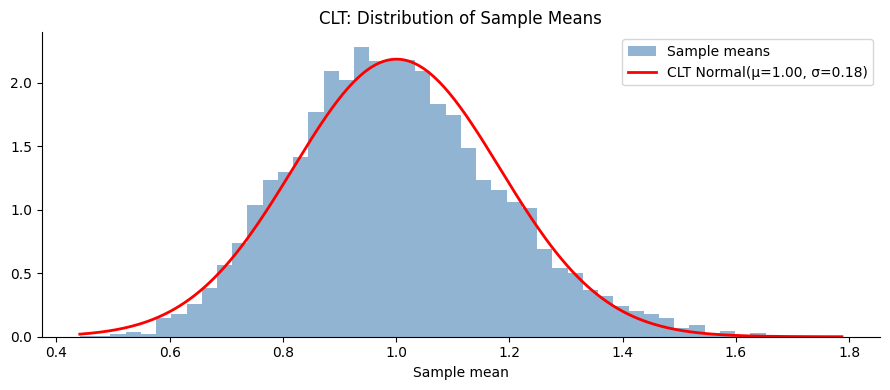

KS test p-value: 0.0054 → Approximately normal? False


In [26]:
np.random.seed(7)                                        # fix random seed so results are reproducible
population=np.random.exponential(scale=1.0,size=100_000)  # create a large population from an exponential distribution (skewed, not normal)

n_samples=5000    # number of times we will draw a sample and record its mean
sample_size=30    # how many people we pick in each sample

sample_means=np.array([                                  # build an array of 5000 sample means
    np.random.choice(population,size=sample_size,replace=False).mean()  # draw 30 values, compute their mean
    for _ in range(n_samples)                            # repeat this 5000 times
])

pop_mean=population.mean()            # true mean of the whole population
pop_std=population.std()              # true standard deviation of the whole population
clt_std=pop_std/np.sqrt(sample_size)  # CLT prediction: std of sample means = population_std / sqrt(n)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")          # show population stats
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")  # sample mean stats should be close to CLT prediction
print(f"CLT predicted std: {clt_std:.4f}")                                        # show what CLT says the std should be

# Plot histogram of sample means + theoretical normal curve ──────────────────
fig,ax=plt.subplots()
ax.hist(sample_means,bins=50,density=True,color='steelblue',alpha=0.6,label='Sample means')  # histogram of the 5000 sample means
x_curve=np.linspace(sample_means.min(),sample_means.max(),300)         # x values for the theoretical normal curve
ax.plot(x_curve,stats.norm.pdf(x_curve,pop_mean,clt_std),              # draw the theoretical normal distribution
        color='red',lw=2,label=f'CLT Normal(μ={pop_mean:.2f}, σ={clt_std:.2f})')  # label it with the CLT parameters
ax.legend()                                                             # show legend
ax.set_xlabel('Sample mean')                                            # label x-axis
ax.set_title('CLT: Distribution of Sample Means')                       # add title
plt.tight_layout()
plt.show()

# KS test: are the sample means approximately normally distributed? ───────────
ks_result=stats.kstest(sample_means,'norm',args=(pop_mean,clt_std))     # compare sample means against the CLT normal distribution
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue>0.05}")  # large p means yes

**CLT Reflection (6.4):**

> The Central Limit Theorem tells us that no matter how weird or skewed the original population is, the distribution of sample means will become approximately normal as the sample size grows. This matters enormously in statistics and machine learning because many classical tests (t-tests, confidence intervals, linear regression inference) assume normality — the CLT is the mathematical reason those assumptions are justified even when the raw data is not normal, as long as the sample is large enough (roughly n ≥ 30). In ML it also underlies why averaging predictions (ensembling) tends to reduce variance and produce more stable estimates.

---
## 🏁 Submission Checklist

Before submitting, verify:

- [x] All `assert` blocks pass without errors
- [x] All `# YOUR CODE HERE` cells are filled
- [x] All markdown reflection cells are filled in your own words
- [x] All plots render with labels and titles
- [x] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`